Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]

Content
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The data set includes information about:

Customers who left within the last month – the column is called Churn
Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
Demographic info about customers – gender, age range, and if they have partners and dependents

import all the dependencies 

In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost  
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression as linr


from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score,roc_auc_score


import dataset and get the basic information about the dataset ->

In [159]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [160]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [161]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


we used info , head and describe to understand our data 

now we will check the target variable (churn) to see wether any imbalance exists or not

In [162]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

now we will visualize the above thing 

<Axes: xlabel='Churn'>

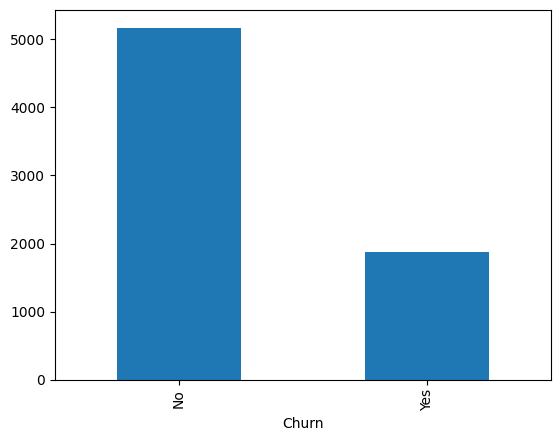

In [163]:
df['Churn'].value_counts().plot(kind='bar')

As we can see there are more no's then yes 

now we will move to data cleaning ->

as we can see total charges column is a string so first we will convert it into numerical 

In [164]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

now we will find the missing values 

In [165]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [166]:
df = df.drop('customerID', axis=1)

In [167]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [168]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [169]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

<Axes: >

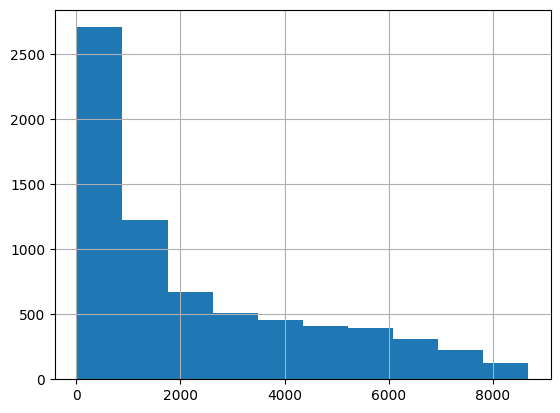

In [170]:
df['TotalCharges'].describe()
df['TotalCharges'].hist()

as the following distribution is skewed we will add median values to the missing data 

In [171]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())

now we will proceed to model the dataset based on which we can make predictions and understand which type  of customers are leaving

In [172]:
x = df.drop('Churn',axis=1)

In [173]:
y=df['Churn']

In [174]:
x=pd.get_dummies(x,drop_first=True)

In [175]:
x.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65


In [176]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [177]:
x.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

now we will split the data for training and testing 

In [178]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

now we will train the model based on the training data and predict values based on that

now we will scale the data 
Why Scaling?
Scaling is used to bring all numerical features to a similar range.
This prevents columns with large values from dominating smaller-value columns.
It helps models like Logistic Regression, KNN, SVM, and Neural Networks learn faster and more accurately.
Scaling also improves convergence and reduces training time.
Common methods: StandardScaler, MinMaxScaler.
usually if not scaled error like this comes STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100). 

as the difference in values of column 1 and column 2 is very large so model has to take more iterations ( compute more ) or more time to learn, One small number, one huge number.Model struggles to balance both. 
hence we always check wether scaling needs to be done or not usually except decision trees , xgboost and random forest we always scale the data 
Default tries are too low
Model gets only 100 chances by default in logistic regression

In [179]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [180]:
from sklearn.linear_model import LogisticRegression as lr
model1=lr(max_iter=2000)
model1.fit(x_train_scaled,y_train)
y_predict =model1.predict(x_test_scaled)

now we will check accuracy of the model 

In [181]:
accuracy=accuracy_score(y_test,y_predict)

In [182]:
print(accuracy)

0.815471965933286


so this is our baseline model which has roughly 81.5 percent accuracy

In [183]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



this classification report tells us ->
Precision for churn = when model says churn, how often right?
Recall for churn = how many actual churners it caught
F1-score = balance of both

In [184]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_predict))

[[933 103]
 [157 216]]


now we will do balanced logistic regression , right now what the model is doing is thinking that the number of stay is more than the number of churn hence predict stay more than churn for better accuracy because our dataset has imbalance as Stay (0) = many, Churn (1) = fewer . 
so we will use class_weight=balanced 
What class_weight='balanced' does
It tells the model:
Mistakes on minority class (churn) matter more.
So missing a churner gets penalized more during training.
That pushes model to pay more attention to churn patterns.

In Practice
Without class weight:
High accuracy
Lower churn recall

With class weight:
Better churn recall
Sometimes lower accuracy
More aggressive churn predictions

so now we will train a second model 

In [185]:
model2=lr(class_weight='balanced',max_iter=2000)
model2.fit(x_train_scaled,y_train)
y_predict=model2.predict(x_test_scaled)

now we will check accuracy of the model 

In [186]:
accuracy = accuracy_score(y_test,y_predict)

In [187]:
accuracy

0.7565649396735273

In [188]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.93      0.73      0.81      1036
           1       0.53      0.84      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



In [189]:
print(confusion_matrix(y_test,y_predict))

[[754 282]
 [ 61 312]]


as we can see here the accuracy is low but the recall rate for churn is high 

now we will see why the customers are churning 

In [190]:
coeff = pd.DataFrame({
    'feature':x.columns ,
    'coefficients':model2.coef_[0] }) 

so as we can see the monthly charges has the highest coefficient ( pushing y predict more towards 1 ) so people who pay higher monthly charges and  total charges are likely to churn first
as we can see the tenure has the lowest coefficient ( pushing y more towards 0 ) so people who have stayed with the company for longer period of time are likely to stay 

In [191]:
print(coeff)

             feature  coefficients
0             gender     -0.018148
1      SeniorCitizen      0.062132
2            Partner      0.024894
3         Dependents     -0.078788
4             tenure     -1.194596
5       PhoneService     -0.295086
6      MultipleLines      0.048670
7    InternetService      0.155614
8     OnlineSecurity     -0.244755
9       OnlineBackup     -0.133017
10  DeviceProtection     -0.079857
11       TechSupport     -0.209618
12       StreamingTV     -0.007916
13   StreamingMovies      0.036692
14          Contract     -0.641695
15  PaperlessBilling      0.167503
16     PaymentMethod      0.060697
17    MonthlyCharges      0.670532
18      TotalCharges      0.550339


In [192]:
probs = model2.predict_proba(x_test_scaled)[:,1]

In [193]:
print(probs)

[0.81989776 0.16106351 0.01454212 ... 0.10943866 0.04259988 0.76135021]


In [194]:
roc_auc_score(y_test,probs)

0.8612277060668481

In [195]:
from xgboost import XGBClassifier 
model3=XGBClassifier()
model3.fit(x_train,y_train)
y_pred3=model3.predict(x_test)

now we will see accuracy of the xgboost model 

In [196]:
accuracy3=accuracy_score(y_test,y_pred3)

In [197]:
accuracy3

0.794180269694819

In [198]:
print(classification_report(y_test,y_pred3))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1036
           1       0.64      0.52      0.57       373

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [199]:
print(roc_auc_score(y_test,y_pred3))

0.7064821907315205


XGBoost got higher accuracy than logistic
Because it predicts non-churn better.
But for actual churn business goal:
It got much worse.
Recall collapsed:
0.84  -> 0.52

Compared Logistic Regression and XGBoost for churn prediction. Despite higher complexity, 
XGBoost underperformed a balanced logistic baseline on recall and ROC-AUC,
so the interpretable logistic model was preferred.

comparison table of all the scores between logistic regression and xgb model 

Model	          Accuracy Recall(1) Precision(1) F1(1)	ROC-AUC
LogisticBalanced	0.76	0.84	   0.53	      0.65	 0.861
XGBoostDefault	    0.79	0.52	  0.64	      0.57	 0.706

max_depth = depth of each tree , 
n_estimators = number of total trees , 
learning rate = 
scale_pos_weight = Controls class imbalance sensitivity. 
What Happens Internally
During training, XGBoost minimizes error.
Every wrong prediction creates a penalty (loss).
Normally:
Wrong class 0 prediction = normal penalty
Wrong class 1 prediction = normal penalty
With:scale_pos_weight = 19
Mistakes on positive class (1) become 19x more important Which forces trees to search harder for positive-class patterns.
usuallly we take scale_pos_weight = total no. of negatives / total no. of positives 
so here negatives/postives = 5174 / 1869 ≈ 2.8

scalepos if recall low of minority class , max depth high if underfitting low if overfitting , no. of estimators same as max depth and learning rate you experiment . 

In [276]:
model4=XGBClassifier(
    max_depth=3,
    n_estimators=200,
    learning_rate=0.05,
    scale_pos_weight=3)

In [277]:
model4.fit(x_train,y_train)
pred4 = model4.predict(x_test)
accuracy = accuracy_score(y_test,pred4)

In [278]:
print(accuracy)

0.752306600425834


In [279]:
print(classification_report(y_test,pred4))

              precision    recall  f1-score   support

           0       0.93      0.72      0.81      1036
           1       0.52      0.85      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.75      0.77      1409



In [280]:
print(roc_auc_score(y_test,pred4))

0.7826658523709462


now we will check wether there is any overfitting or not 

In [281]:
pred5=model4.predict(x_train)
print(accuracy_score(y_train,pred5))

0.7578984735534257


if there was strong overfitting than training accuracy significantly higher than test accuracy.

SUMMARY: 
Compared Logistic Regression and XGBoost models.
Balanced Logistic Regression achieved the best ROC-AUC (0.861) with strong churn recall.
XGBoost achieved competitive recall after tuning but lower ranking performance.

In [282]:
summary = pd.DataFrame({
    "Model": ["Logistic Balanced", "XGBoost Tuned"],
    "Accuracy": [0.76, 0.75],
    "Recall_Churn": [0.84, 0.85],
    "F1_Churn": [0.65, 0.64],
    "ROC_AUC": [0.861, 0.783]
})
summary

,Model,Accuracy,Recall_Churn,F1_Churn,ROC_AUC
0,Logistic Balanced,0.76,0.84,0.65,0.861
1,XGBoost Tuned,0.75,0.85,0.64,0.783


KEY CHURN DRIVERS:
- Higher monthly charges
- Lower tenure
- Month-to-month style contract patterns
- Lack of support/security services

Recommended retention actions:

1. Target high monthly charge customers with discounts or bundles.
2. Improve onboarding for new customers in first 3 months.
3. Convert month-to-month customers into annual plans.
4. Bundle tech support / security features.
5. Use churn probability scores to prioritize outreach.

In [284]:
risk = pd.cut(
    probs,
    bins=[0,0.4,0.7,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

pd.Series(risk).value_counts()

Low Risk       679
Medium Risk    367
High Risk      363
Name: count, dtype: int64

These Customers can be segmented for different retention campaigns.

Balanced Logistic Regression was selected as the preferred model due to strong recall, best ROC-AUC, and interpretability.
This model can help prioritize retention campaigns and reduce customer churn.